Total beacon records: 2546
Time range: 5.74 .. 214.94 s

 [1] TEMPERATURE COLUMN CHECK
  p1_temp: n=2200, min=17.40, max=30.30, range=12.90, unique=18
  p2_temp: n=1901, min=17.60, max=33.40, range=15.80, unique=21

Outlier rejection:
       raw: 43
     clean: 1355
      temp: 0
        ok: 2728
Total valid link records: 2728

 [2] PER-LINK SUMMARY
  link |    n |   raw_mean |  clean_mean |  clean_std |  rssi_mean |  temp_mean
------------------------------------------------------------------------------------
  2->4 |  551 |   +41.8640 |     +2.5072 |     0.0192 |     -62.91 |      28.40
  3->2 |  550 |   +48.6319 |    +11.2942 |     0.0258 |     -63.75 |      29.92
  3->4 |  789 |   +49.2235 |    +11.1119 |     0.2014 |     -68.97 |      29.10
  4->2 |  838 |   +40.8706 |     +2.6477 |     0.0305 |     -63.91 |      25.41

 [3] BIAS vs CONSTANT GROUND TRUTH

  link |    n |      GT |  bias_mean |   bias_std |   bias_min |   bias_max
--------------------------------------------------

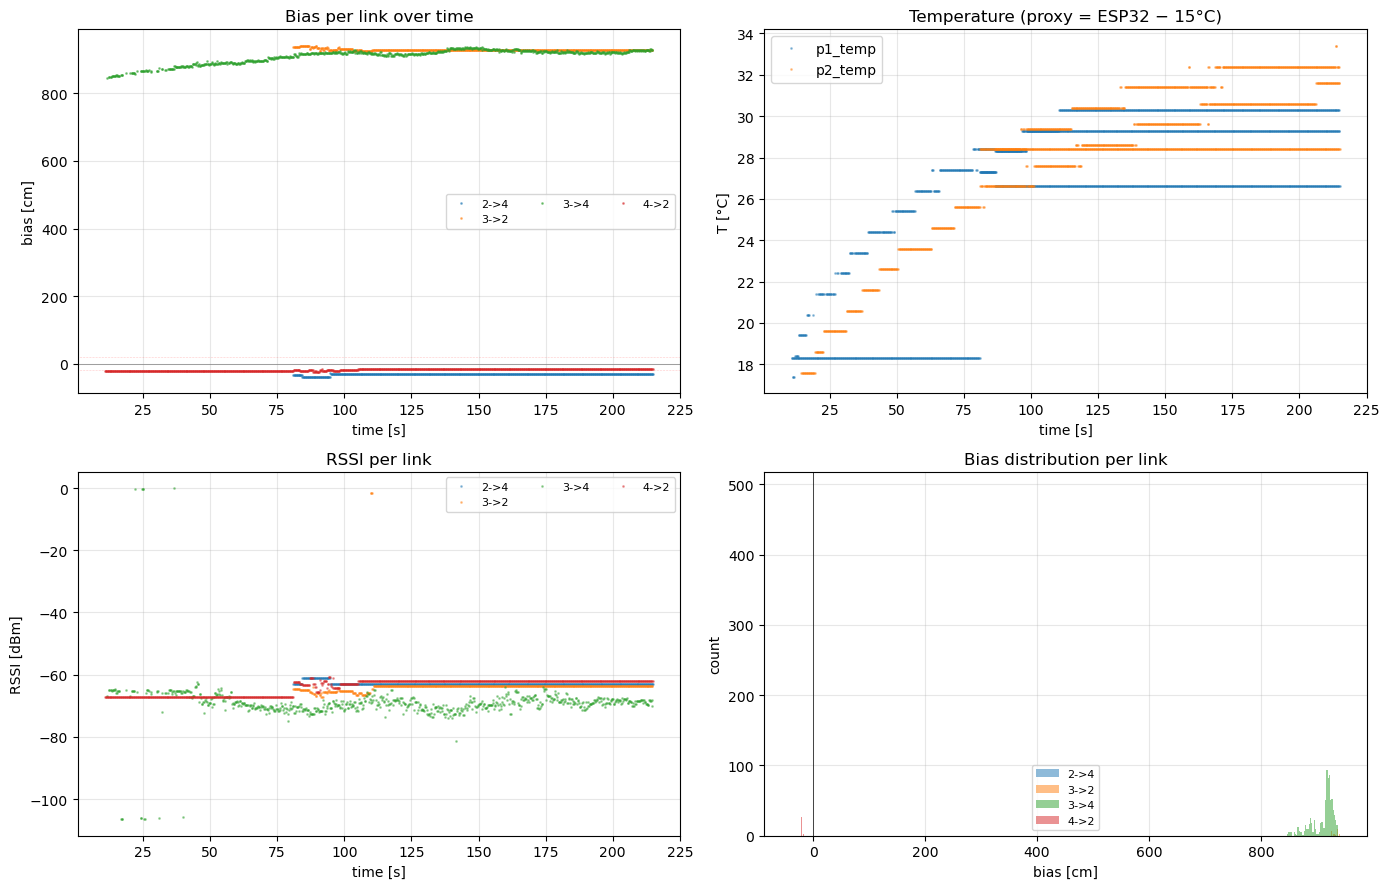

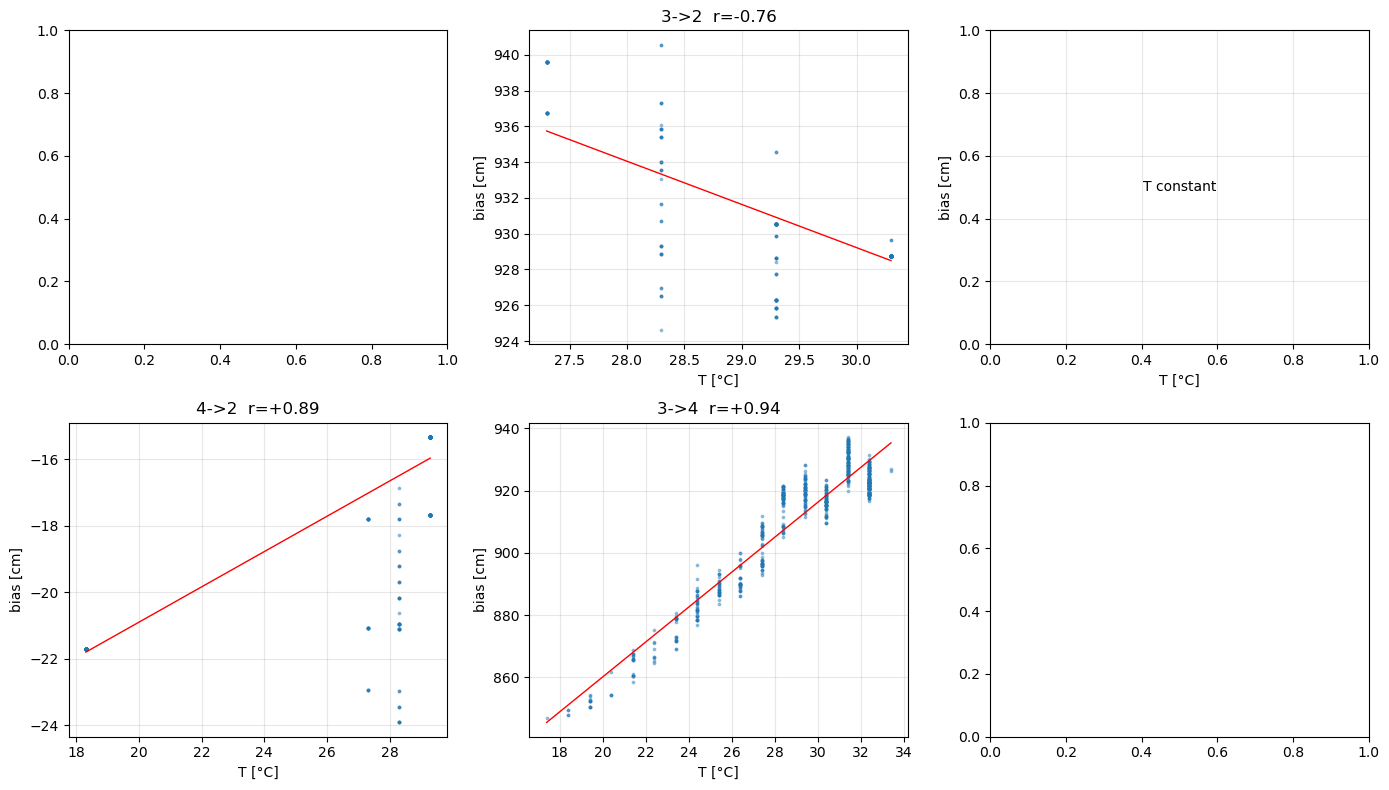

In [1]:
# ============================================================
# Gateway analysis — fourth test (no CFO, proxy temperature)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 320)
np.set_printoptions(precision=4, suppress=True)

# ------------------------------------------------------------
# 0. Load
# ------------------------------------------------------------
FILE = "fourth_test.csv"

rows = []
with open(FILE, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        rows.append(line)

header = rows[0].split(",")
df = pd.DataFrame([r.split(",") for r in rows[1:]], columns=header)
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"Total beacon records: {len(df)}")
print(f"Time range: {df['rx_ms'].iloc[0]/1000:.2f} .. "
      f"{df['rx_ms'].iloc[-1]/1000:.2f} s")

# ------------------------------------------------------------
# 1. Sanity: temperature column
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [1] TEMPERATURE COLUMN CHECK")
print("=" * 96)
for slot in (1, 2):
    tcol = f"p{slot}_temp"
    if tcol not in df.columns: continue
    tv = df[tcol].values
    tv = tv[tv > 0]
    if len(tv) < 5: continue
    print(f"  {tcol}: n={len(tv)}, min={tv.min():.2f}, "
          f"max={tv.max():.2f}, range={tv.max()-tv.min():.2f}, "
          f"unique={len(np.unique(np.round(tv, 2)))}")

# ------------------------------------------------------------
# 2. Build link records with strict filtering
# ------------------------------------------------------------
UWB_RAW_MIN, UWB_RAW_MAX     = 0.1, 50.0
UWB_CLEAN_MIN, UWB_CLEAN_MAX = -5.0, 15.0
TEMP_MIN, TEMP_MAX           = 15.0, 60.0

link_records = []
counts = {"raw": 0, "clean": 0, "temp": 0, "ok": 0}

for _, row in df.iterrows():
    sender = int(row["senderId"])
    for slot in (1, 2):
        pid = int(row[f"p{slot}_id"])
        if pid == 0: continue
        raw   = row[f"p{slot}_raw"]
        clean = row[f"p{slot}_clean"]
        temp  = row[f"p{slot}_temp"]
        if abs(raw) < 1e-6: continue
        if not (UWB_RAW_MIN < raw < UWB_RAW_MAX):
            counts["raw"] += 1; continue
        if not (UWB_CLEAN_MIN < clean < UWB_CLEAN_MAX):
            counts["clean"] += 1; continue
        if not (TEMP_MIN < temp < TEMP_MAX):
            counts["temp"] += 1; continue
        counts["ok"] += 1

        link_records.append({
            "rx_ms":   row["rx_ms"],
            "sender":  sender,
            "peer":    pid,
            "frame":   int(row["frameId"]),
            "raw":     raw,
            "clean":   clean,
            "rssi":    row[f"p{slot}_rssi"],
            "fp":      row[f"p{slot}_fp"],
            "temp":    temp,
            "lde":     row[f"p{slot}_lde"],
        })

print(f"\nOutlier rejection:")
for k, v in counts.items():
    print(f"  {k:>8s}: {v}")

links = pd.DataFrame(link_records)
links["link"] = links["sender"].astype(str) + "->" + links["peer"].astype(str)
links["t_s"]  = links["rx_ms"] / 1000.0

print(f"Total valid link records: {len(links)}")

GT_DIST = {
    "2->3": 2.000, "3->2": 2.000,
    "3->4": 2.000, "4->3": 2.000,
    "2->4": 2.828, "4->2": 2.828,
}

# ------------------------------------------------------------
# 3. Per-link summary
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [2] PER-LINK SUMMARY")
print("=" * 96)
print(f"{'link':>6s} | {'n':>4s} | {'raw_mean':>10s} | "
      f"{'clean_mean':>11s} | {'clean_std':>10s} | "
      f"{'rssi_mean':>10s} | {'temp_mean':>10s}")
print("-" * 84)

for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    print(f"{lk:>6s} | {len(grp):>4d} | "
          f"{grp['raw'].mean():>+10.4f} | "
          f"{grp['clean'].mean():>+11.4f} | "
          f"{grp['clean'].std():>10.4f} | "
          f"{grp['rssi'].mean():>+10.2f} | "
          f"{grp['temp'].mean():>10.2f}")

# ------------------------------------------------------------
# 4. Bias vs GT
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [3] BIAS vs CONSTANT GROUND TRUTH")
print("=" * 96)
print(f"\n{'link':>6s} | {'n':>4s} | {'GT':>7s} | "
      f"{'bias_mean':>10s} | {'bias_std':>10s} | "
      f"{'bias_min':>10s} | {'bias_max':>10s}")
print("-" * 82)

bias_summary = {}
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    gt = GT_DIST[lk]
    bias = (grp["clean"] - gt) * 100
    bias_summary[lk] = {
        "mean": float(bias.mean()),
        "std":  float(bias.std()),
        "n":    len(grp),
    }
    print(f"{lk:>6s} | {len(grp):>4d} | {gt:>7.3f} | "
          f"{bias.mean():>+10.2f} | {bias.std():>10.2f} | "
          f"{bias.min():>+10.2f} | {bias.max():>+10.2f}")
print("  (bias in cm)")

# ------------------------------------------------------------
# 5. Link asymmetry
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [4] LINK ASYMMETRY")
print("=" * 96)
print("  Previous tests:")
print("    Test 2 (no CFO, no temp):  2↔3=83  3↔4=98  2↔4=12 cm")
print("    Test 3 (with CFO, bad temp): 2↔3=187 3↔4=84 2↔4=95 cm")
print("  Current test (no CFO, proxy temp):")
print()
total_asym = 0
for a, b in [(2, 3), (3, 4), (2, 4)]:
    fk = f"{a}->{b}"
    rk = f"{b}->{a}"
    if fk not in bias_summary or rk not in bias_summary: continue
    fb = bias_summary[fk]["mean"]
    rb = bias_summary[rk]["mean"]
    asym = abs(fb - rb)
    total_asym += asym
    print(f"    {a}↔{b}: fwd={fb:+.2f}, rev={rb:+.2f}, |Δ|={asym:.2f} cm")
print(f"\n  Total asymmetry: {total_asym:.2f} cm")

# ------------------------------------------------------------
# 6. Bias evolution over time
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [5] BIAS EVOLUTION OVER TIME (4 windows)")
print("=" * 96)
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    if len(grp) < 20: continue
    t = grp["t_s"].values
    b = (grp["clean"].values - GT_DIST[lk]) * 100
    order = np.argsort(t)
    t = t[order]; b = b[order]
    n = len(b); q = n // 4
    w = [b[:q].mean(), b[q:2*q].mean(),
         b[2*q:3*q].mean(), b[3*q:].mean()]
    print(f"  {lk}: W1={w[0]:>+7.2f}  W2={w[1]:>+7.2f}  "
          f"W3={w[2]:>+7.2f}  W4={w[3]:>+7.2f}  "
          f"spread={max(w)-min(w):>6.2f} cm")

# ------------------------------------------------------------
# 7. Bias vs temperature (key for thermal model)
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [6] BIAS vs TEMPERATURE (per link)")
print("=" * 96)
print(f"{'link':>6s} | {'corr(bias,T)':>14s} | "
      f"{'slope [cm/°C]':>14s} | {'T_range':>10s}")
print("-" * 60)
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    if len(grp) < 50: continue
    bias = (grp["clean"].values - GT_DIST[lk]) * 100
    t = grp["temp"].values
    if t.std() < 0.1: continue   # temperature constant, skip
    corr = np.corrcoef(bias, t)[0, 1]
    A = np.vstack([t, np.ones(len(t))]).T
    coef, *_ = np.linalg.lstsq(A, bias, rcond=None)
    print(f"{lk:>6s} | {corr:>+14.3f} | {coef[0]:>+14.3f} | "
          f"{t.max()-t.min():>10.2f}")

# ------------------------------------------------------------
# 8. RSSI summary
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [7] RSSI PER LINK")
print("=" * 96)
print(f"{'link':>6s} | {'mean':>9s} | {'std':>8s} | "
      f"{'min':>9s} | {'max':>9s}")
print("-" * 48)
for lk, grp in links.groupby("link"):
    r = grp["rssi"].values
    print(f"{lk:>6s} | {r.mean():>+9.2f} | {r.std():>8.2f} | "
          f"{r.min():>+9.2f} | {r.max():>+9.2f}")

# ------------------------------------------------------------
# 9. LDE error count
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [8] LDE ERROR COUNT")
print("=" * 96)
for lk, grp in links.groupby("link"):
    n_err = int((grp["lde"] > 0).sum())
    print(f"  {lk}: {n_err} / {len(grp)} ({100*n_err/len(grp):.2f}%)")

# ------------------------------------------------------------
# 10. Coverage
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [9] COVERAGE")
print("=" * 96)
for sender in sorted(df["senderId"].unique()):
    sub = df[df["senderId"] == sender]
    n_beacons = len(sub)
    frame_span = int(sub["frameId"].iloc[-1] - sub["frameId"].iloc[0])
    print(f"  R{int(sender)}: {n_beacons} beacons over {frame_span} frames, "
          f"loss = {100*(1-n_beacons/(frame_span+1)):.2f}%")

# ------------------------------------------------------------
# 11. PLOT 1 — Bias per link over time
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Bias vs time
ax = axes[0, 0]
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    bias = (grp["clean"] - GT_DIST[lk]) * 100
    ax.plot(grp["t_s"], bias, ".", ms=2, alpha=0.5, label=lk)
ax.axhline(0, color="gray", lw=0.5)
ax.axhline(+20, color="red", ls=":", lw=0.4, alpha=0.4)
ax.axhline(-20, color="red", ls=":", lw=0.4, alpha=0.4)
ax.set_xlabel("time [s]"); ax.set_ylabel("bias [cm]")
ax.set_title("Bias per link over time")
ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.3)

# (b) Temperature over time
ax = axes[0, 1]
for slot in (1, 2):
    tcol = f"p{slot}_temp"
    if tcol not in df.columns: continue
    sub = df[df[tcol] > 0]
    ax.plot(sub["rx_ms"] / 1000.0, sub[tcol], ".", ms=2, alpha=0.4,
            label=f"p{slot}_temp")
ax.set_xlabel("time [s]"); ax.set_ylabel("T [°C]")
ax.set_title("Temperature (proxy = ESP32 − 15°C)")
ax.legend(); ax.grid(True, alpha=0.3)

# (c) RSSI vs time
ax = axes[1, 0]
for lk, grp in links.groupby("link"):
    ax.plot(grp["t_s"], grp["rssi"], ".", ms=2, alpha=0.4, label=lk)
ax.set_xlabel("time [s]"); ax.set_ylabel("RSSI [dBm]")
ax.set_title("RSSI per link")
ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.3)

# (d) Bias histogram
ax = axes[1, 1]
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    bias = (grp["clean"] - GT_DIST[lk]) * 100
    ax.hist(bias, bins=40, alpha=0.5, label=lk)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("bias [cm]"); ax.set_ylabel("count")
ax.set_title("Bias distribution per link")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fourth_test_analysis.png", dpi=120)
plt.show()

# ------------------------------------------------------------
# 12. PLOT 2 — Bias vs Temperature scatter (per link)
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
pairs = [("2->3", 0, 0), ("3->2", 0, 1), ("2->4", 0, 2),
         ("4->2", 1, 0), ("3->4", 1, 1), ("4->3", 1, 2)]
for lk, r, c in pairs:
    ax = axes[r, c]
    grp = links[links["link"] == lk]
    if len(grp) < 20 or lk not in GT_DIST: continue
    bias = (grp["clean"] - GT_DIST[lk]) * 100
    t = grp["temp"].values
    if t.std() < 0.05:
        ax.text(0.5, 0.5, "T constant",
                ha="center", va="center", transform=ax.transAxes)
    else:
        ax.scatter(t, bias, s=3, alpha=0.4)
        A = np.vstack([t, np.ones(len(t))]).T
        coef, *_ = np.linalg.lstsq(A, bias, rcond=None)
        r_corr = np.corrcoef(bias, t)[0, 1]
        xx = np.linspace(t.min(), t.max(), 20)
        ax.plot(xx, coef[0]*xx + coef[1], "r-", lw=1)
        ax.set_title(f"{lk}  r={r_corr:+.2f}")
    ax.set_xlabel("T [°C]"); ax.set_ylabel("bias [cm]")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fourth_test_temp_corr.png", dpi=120)
plt.show()

In [ ]:
# ============================================================
# Gateway analysis — fourth test (no CFO, proxy temperature)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 320)
np.set_printoptions(precision=4, suppress=True)

# ------------------------------------------------------------
# 0. Load
# ------------------------------------------------------------
FILE = "fourth_test.csv"

rows = []
with open(FILE, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        rows.append(line)

header = rows[0].split(",")
df = pd.DataFrame([r.split(",") for r in rows[1:]], columns=header)
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"Total beacon records: {len(df)}")

# ------------------------------------------------------------
# 1. Extract RAW link records with NO clean-based filter
# ------------------------------------------------------------
# The clean filter (-5, 15) removed 1355 records, mostly links
# where R3 is initiator (clean ≈ -8). We keep them and analyze
# the asymmetry directly.
link_records = []
for _, row in df.iterrows():
    sender = int(row["senderId"])
    for slot in (1, 2):
        pid = int(row[f"p{slot}_id"])
        if pid == 0: continue
        raw   = row[f"p{slot}_raw"]
        if abs(raw) < 1e-6: continue
        if not (0.1 < raw < 200.0): continue

        link_records.append({
            "rx_ms":   row["rx_ms"],
            "sender":  sender,
            "peer":    pid,
            "frame":   int(row["frameId"]),
            "raw":     raw,
            "clean":   row[f"p{slot}_clean"],
            "rssi":    row[f"p{slot}_rssi"],
            "fp":      row[f"p{slot}_fp"],
            "temp":    row[f"p{slot}_temp"],
            "lde":     row[f"p{slot}_lde"],
        })

links = pd.DataFrame(link_records)
links["link"] = links["sender"].astype(str) + "->" + links["peer"].astype(str)
links["t_s"]  = links["rx_ms"] / 1000.0
print(f"Total raw link records: {len(links)}")

# ------------------------------------------------------------
# 2. Raw bias table — the key diagnostic
# ------------------------------------------------------------
GT_DIST = {
    "2->3": 2.000, "3->2": 2.000,
    "3->4": 2.000, "4->3": 2.000,
    "2->4": 2.828, "4->2": 2.828,
}

print("\n" + "=" * 96)
print(" [1] RAW BIAS PER LINK  (before any calibration)")
print("=" * 96)
print(f"{'link':>6s} | {'n':>4s} | {'GT':>7s} | "
      f"{'raw_mean':>11s} | {'raw_bias':>11s} | "
      f"{'raw_std':>10s} | {'role_of_R3':>11s}")
print("-" * 82)

for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    gt = GT_DIST[lk]
    rb = grp["raw"].mean() - gt

    # Classify R3 role
    s, p = map(int, lk.split("->"))
    if s == 3 and p != 3:
        role = "initiator"
    elif p == 3 and s != 3:
        role = "responder"
    else:
        role = "—"

    print(f"{lk:>6s} | {len(grp):>4d} | {gt:>7.3f} | "
          f"{grp['raw'].mean():>+11.4f} | {rb:>+11.3f} | "
          f"{grp['raw'].std():>10.4f} | {role:>11s}")

# ------------------------------------------------------------
# 3. R3 CONSISTENCY CHECK — the smoking gun
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [2] R3 CONSISTENCY CHECK")
print("=" * 96)

# For links that DON'T involve R3 (2↔4), we have a baseline.
# For links that DO involve R3, we check whether the deviation
# is systematic.
baseline_24 = links[links["link"] == "2->4"]["raw"].mean()
baseline_42 = links[links["link"] == "4->2"]["raw"].mean()
print(f"  Baseline link 2->4 raw mean : {baseline_24:+.4f} m  "
      f"(GT=2.828, raw_bias={baseline_24-2.828:+.3f})")
print(f"  Baseline link 4->2 raw mean : {baseline_42:+.4f} m  "
      f"(GT=2.828, raw_bias={baseline_42-2.828:+.3f})")

print("\n  Links involving R3:")
for lk in ["2->3", "3->2", "4->3", "3->4"]:
    if lk not in links["link"].values: continue
    grp = links[links["link"] == lk]
    s, p = map(int, lk.split("->"))
    role = "initiator" if s == 3 else "responder"
    rb = grp["raw"].mean() - GT_DIST[lk]
    # If R3 were healthy, raw_bias should be ≈ baseline_24
    deviation = rb - (baseline_24 - 2.828)
    print(f"    {lk}: role={role:>9s}, raw_bias={rb:+.3f} m, "
          f"deviation_from_baseline={deviation*100:+.1f} cm")

# ------------------------------------------------------------
# 4. Temperature correlation per link (bias vs T)
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [3] BIAS vs TEMPERATURE  (per link)")
print("=" * 96)
print("  Uses raw_bias = raw - GT. High correlation confirms")
print("  the thermal model has a real signal to fit.")
print(f"\n{'link':>6s} | {'n':>4s} | "
      f"{'corr(bias,T)':>14s} | {'slope [cm/°C]':>14s} | "
      f"{'T_range [°C]':>14s}")
print("-" * 72)

for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    if len(grp) < 50: continue

    bias = (grp["raw"].values - GT_DIST[lk]) * 100
    t    = grp["temp"].values
    if t.std() < 0.1: continue

    corr = float(np.corrcoef(bias, t)[0, 1])
    A = np.vstack([t, np.ones(len(t))]).T
    coef, *_ = np.linalg.lstsq(A, bias, rcond=None)

    print(f"{lk:>6s} | {len(grp):>4d} | "
          f"{corr:>+14.3f} | {coef[0]:>+14.3f} | "
          f"{t.max()-t.min():>14.2f}")

# ------------------------------------------------------------
# 5. Raw distance over time per link
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [4] RAW DISTANCE EVOLUTION (4 windows, meters)")
print("=" * 96)
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    if len(grp) < 20: continue
    t = grp["t_s"].values
    r = grp["raw"].values
    order = np.argsort(t)
    r = r[order]
    n = len(r); q = n // 4
    w = [r[:q].mean(), r[q:2*q].mean(),
         r[2*q:3*q].mean(), r[3*q:].mean()]
    print(f"  {lk}: W1={w[0]:>+7.3f}  W2={w[1]:>+7.3f}  "
          f"W3={w[2]:>+7.3f}  W4={w[3]:>+7.3f}  "
          f"spread={max(w)-min(w):>6.3f} m")

# ------------------------------------------------------------
# 6. RSSI check — are there pathological readings?
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [5] RSSI CHECK")
print("=" * 96)
print(f"{'link':>6s} | {'mean':>9s} | {'std':>8s} | "
      f"{'min':>9s} | {'max':>9s} | {'n_above_-40':>11s}")
print("-" * 70)
for lk, grp in links.groupby("link"):
    r = grp["rssi"].values
    n_above = int((r > -40).sum())
    print(f"{lk:>6s} | {r.mean():>+9.2f} | {r.std():>8.2f} | "
          f"{r.min():>+9.2f} | {r.max():>+9.2f} | {n_above:>11d}")

# ------------------------------------------------------------
# 7. Frame timing
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [6] TDMA FRAME TIMING")
print("=" * 96)
for sender in sorted(df["senderId"].unique()):
    sub = df[df["senderId"] == sender].reset_index(drop=True)
    if len(sub) < 30: continue
    dt = np.diff(sub["rx_ms"].values)
    dt = dt[(dt > 0) & (dt < 1000)]
    print(f"  R{int(sender)}: n={len(sub)}, "
          f"inter-arrival mean={dt.mean():.1f} ms, "
          f"std={dt.std():.1f} ms  (expected 240)")

# ------------------------------------------------------------
# 8. PLOTS
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Raw distance per link
ax = axes[0, 0]
for lk, grp in links.groupby("link"):
    ax.plot(grp["t_s"], grp["raw"], ".", ms=2, alpha=0.4, label=lk)
ax.set_xlabel("time [s]"); ax.set_ylabel("raw dist [m]")
ax.set_title("Raw UWB distance per link")
ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.3)

# (b) Bias vs temperature (scatter)
ax = axes[0, 1]
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    bias = (grp["raw"] - GT_DIST[lk]) * 100
    ax.scatter(grp["temp"], bias, s=3, alpha=0.4, label=lk)
ax.set_xlabel("T [°C]"); ax.set_ylabel("raw bias [cm]")
ax.set_title("Raw bias vs temperature")
ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.3)

# (c) RSSI per link
ax = axes[1, 0]
for lk, grp in links.groupby("link"):
    ax.plot(grp["t_s"], grp["rssi"], ".", ms=2, alpha=0.4, label=lk)
ax.set_xlabel("time [s]"); ax.set_ylabel("RSSI [dBm]")
ax.set_title("RSSI per link")
ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.3)

# (d) Raw bias histogram per link
ax = axes[1, 1]
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    bias = (grp["raw"] - GT_DIST[lk]) * 100
    ax.hist(bias, bins=40, alpha=0.5, label=lk)
ax.set_xlabel("raw bias [cm]"); ax.set_ylabel("count")
ax.set_title("Raw bias distribution per link")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fourth_test_analysis.png", dpi=120)
plt.show()

Total beacon records: 2546
